In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../csv/nyc_taxi_trip_duration.csv")

In [3]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [4]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [6]:
df.isna().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [7]:
#Good that we don't have any nulls/missing values in this dataset!

In [8]:
# Let's do some data transformation

In [9]:
df['pickup_datetime'] = pd.to_datetime(df.pickup_datetime)
df['dropoff_datetime'] = pd.to_datetime(df.dropoff_datetime)

df['store_and_fwd_flag'] = 1*(df.store_and_fwd_flag == 'Y')

In [10]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,0,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,0,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,0,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,0,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,0,848


In [11]:
# Now, let's check the target variable as well!

In [12]:
df['trip_duration_in_hrs'] = df['trip_duration']/3600

In [13]:
df['trip_duration_in_hrs'].describe()

count    729322.000000
mean          0.264508
std           1.073507
min           0.000278
25%           0.110278
50%           0.184167
75%           0.298611
max         538.815556
Name: trip_duration_in_hrs, dtype: float64

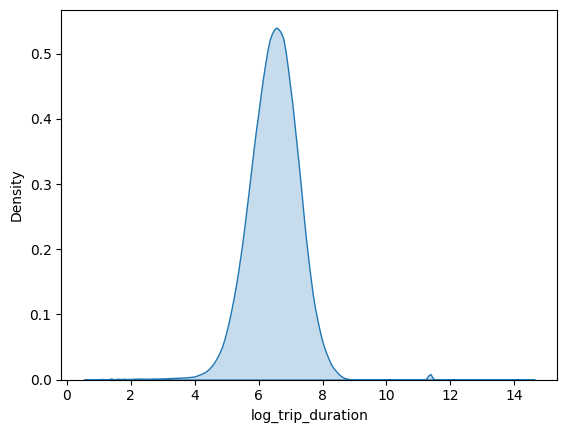

In [14]:
df['log_trip_duration'] = np.log(df['trip_duration'].values + 1)
sns.kdeplot(df['log_trip_duration'], fill=True)
plt.show()

In [15]:
#From the figure, we can make an estimation that most of the rides are around expected time limits with a few outliers around 12.

### Now let's focus on some Univariate analysis

In [22]:
columns = ["passenger_count", "vendor_id", "store_and_fwd_flag"]

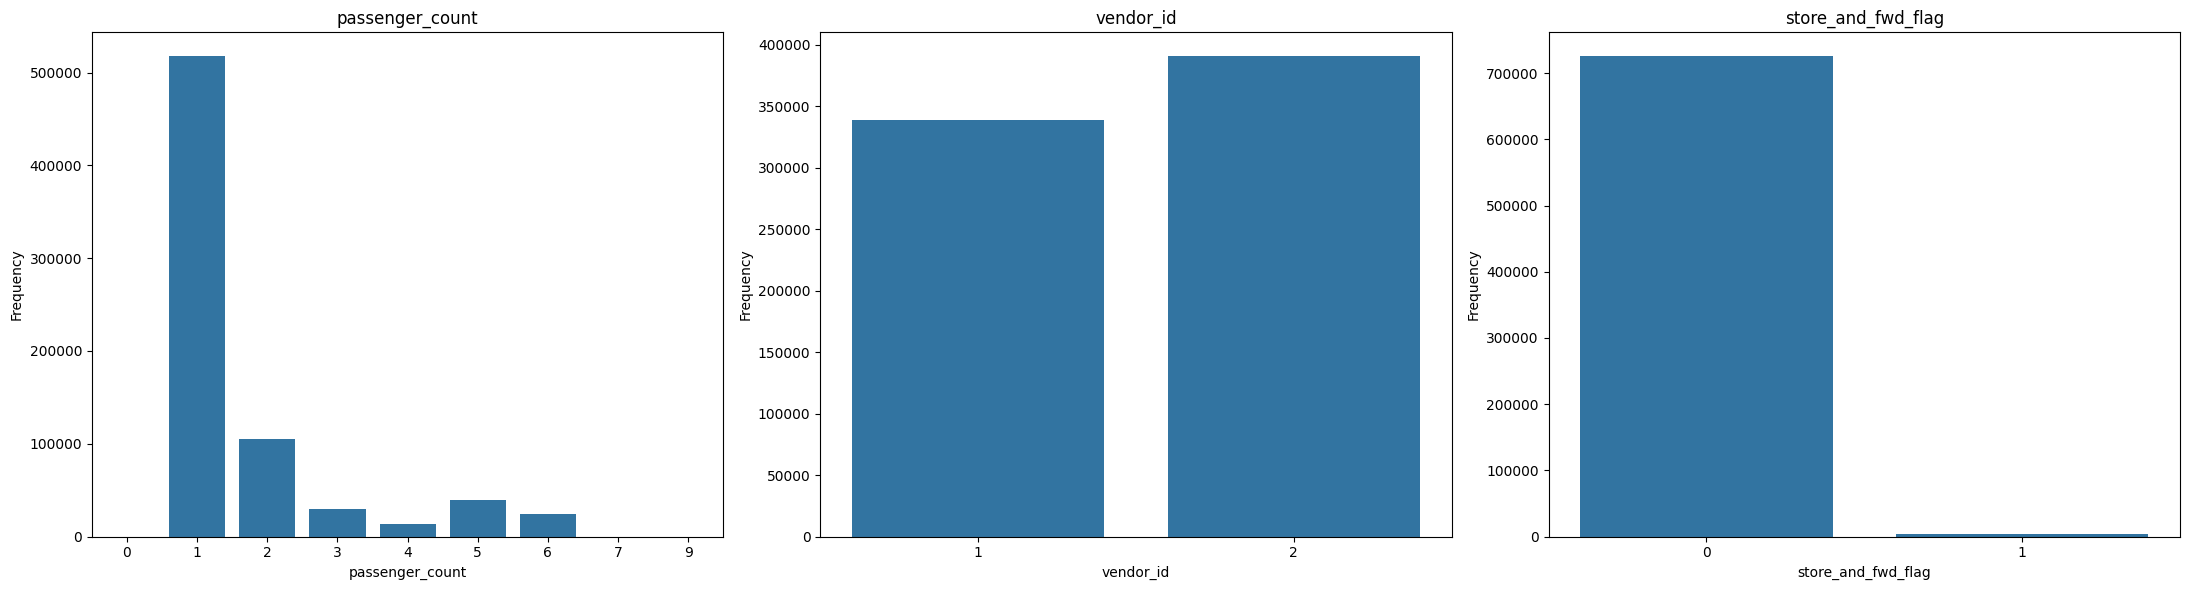

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, col in zip(axes, columns):
    counts = df[col].value_counts().sort_index()

    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [24]:
df['pickup_datetime'].min(), df['pickup_datetime'].max()

(Timestamp('2016-01-01 00:01:14'), Timestamp('2016-06-30 23:59:37'))

In [35]:
df['day_of_week_when_trip_started'] = df['pickup_datetime'].dt.weekday
df['hour_of_day_when_trip_started'] = df['pickup_datetime'].dt.hour

In [36]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_in_hrs,log_trip_duration,day_of_week_when_trip_started,hour_of_day_when_trip_started
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,0,400,0.111111,5.993961,0,16
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,0,1100,0.305556,7.003974,4,23
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,0,1635,0.454167,7.400010,6,17
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,0,1141,0.316944,7.040536,1,9
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,0,848,0.235556,6.744059,2,6


In [37]:
columns = ['day_of_week_when_trip_started','hour_of_day_when_trip_started']

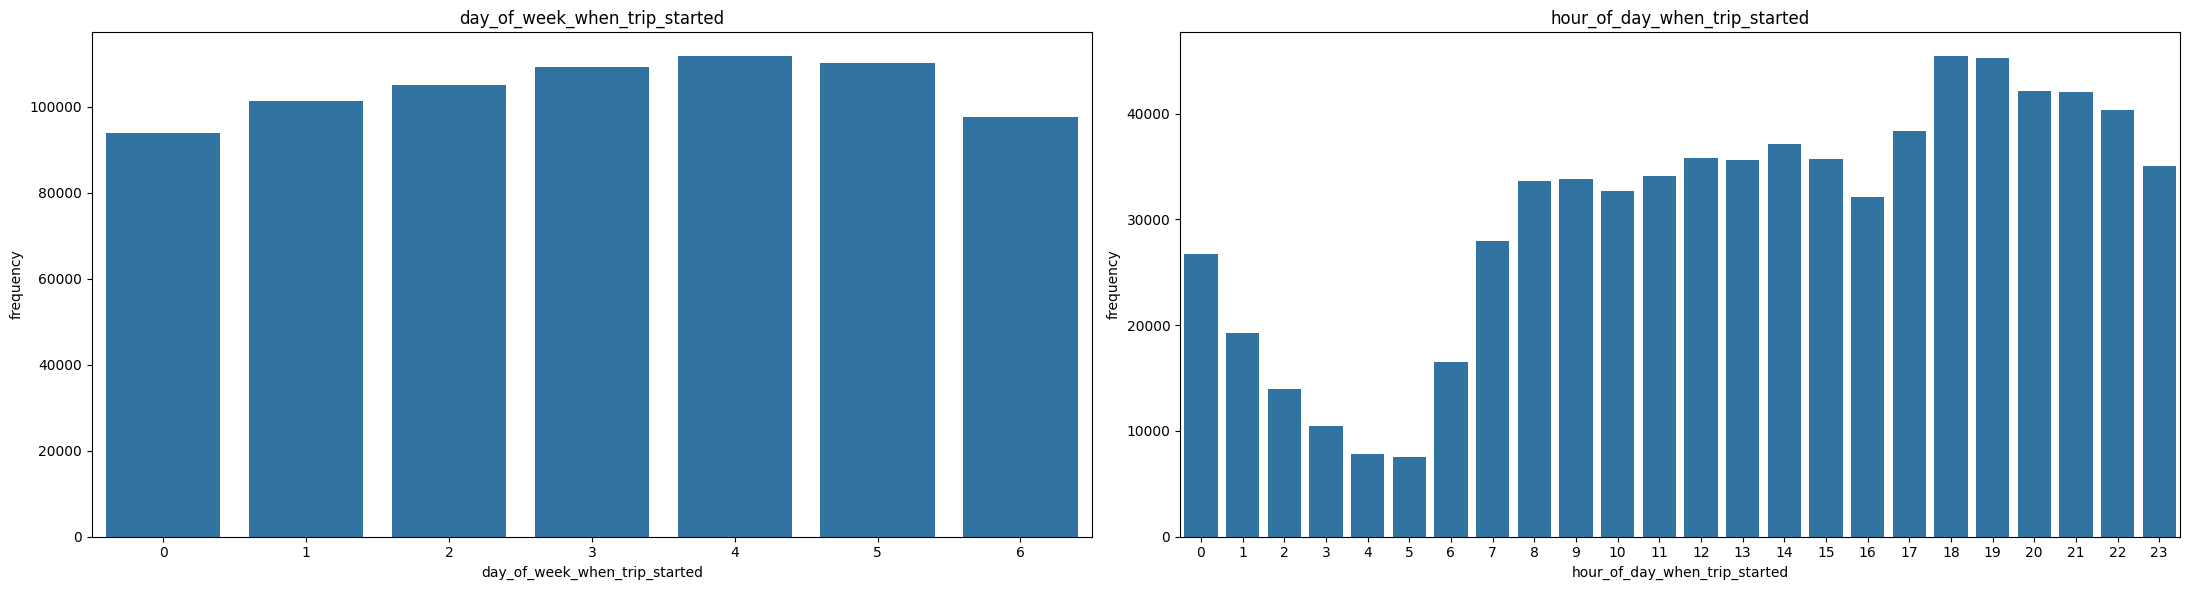

In [42]:
fig, axes = plt.subplots(1,2, figsize=(22,6))

for ax, col in zip(axes, columns):
    counts = df[col].value_counts().sort_index()

    sns.barplot(
    x = counts.index.astype(str),
    y = counts.values,
    ax = ax
    )

    ax.set_title(col),
    ax.set_xlabel(col),
    ax.set_ylabel("frequency")

plt.tight_layout()
plt.show()

In [43]:
# here 0 in first plot is denoting sunday and 6 as saturday
# similarly, 0 in time is 12 am and henceforth

### Now, let's do some Bivariate analysis

In [44]:
# Let's checkout time travelled duration over weekdays

In [46]:
summary_wdays_avg_duration = pd.DataFrame(df.groupby(['day_of_week_when_trip_started'])['trip_duration'].median())

In [49]:
summary_wdays_avg_duration.reset_index(inplace=True)
summary_wdays_avg_duration['unit'] = 1

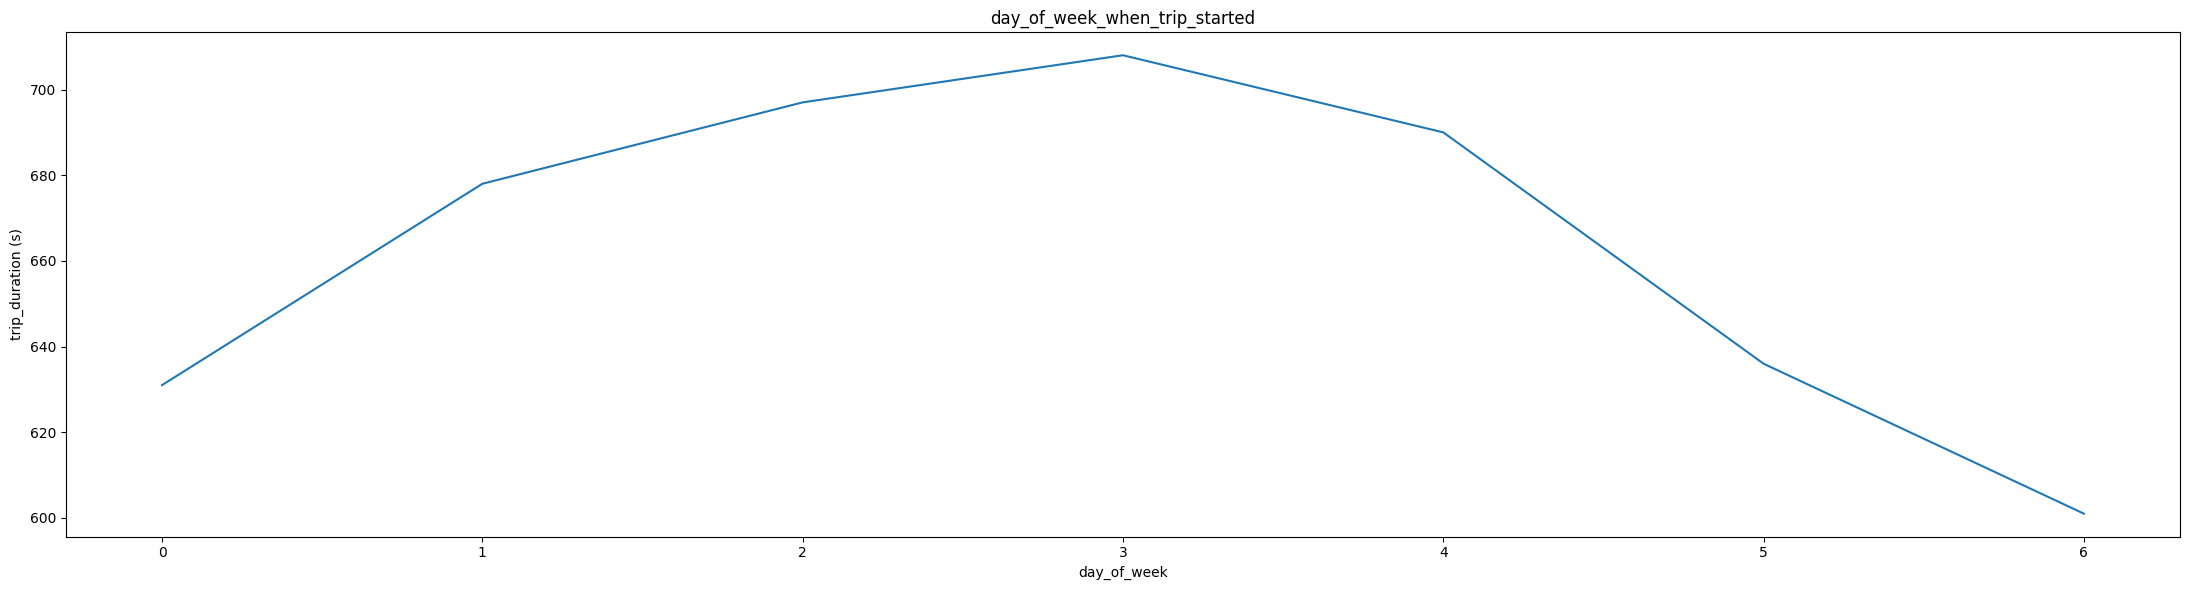

In [58]:
plt.figure(figsize = (22,6))
sns.lineplot(x=summary_wdays_avg_duration['day_of_week_when_trip_started'], y=summary_wdays_avg_duration['trip_duration'])
plt.title('day_of_week_when_trip_started')
plt.xlabel('day_of_week')
plt.ylabel('trip_duration (s)')
plt.tight_layout()
plt.show()

In [75]:
# trip duration over the 24hrs shift

In [79]:
summary_hourly_avg_duration = pd.DataFrame(df.groupby(['hour_of_day_when_trip_started'])['trip_duration'].median())

In [80]:
summary_hourly_avg_duration.reset_index(inplace=True)

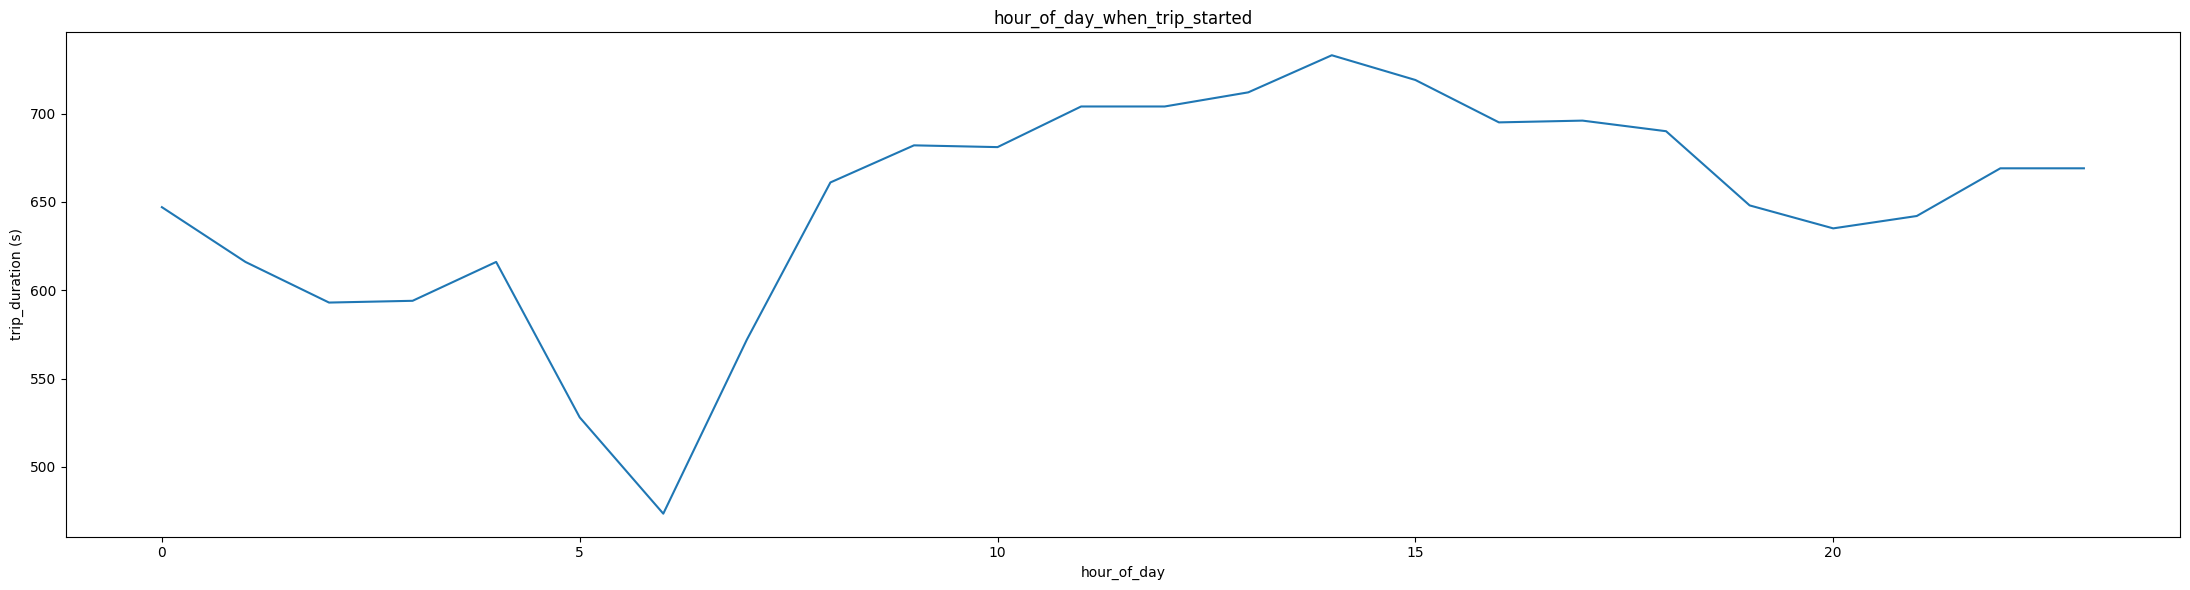

In [81]:
plt.figure(figsize = (22,6))
sns.lineplot(x=summary_hourly_avg_duration['hour_of_day_when_trip_started'], y=summary_hourly_avg_duration['trip_duration'])
plt.title('hour_of_day_when_trip_started')
plt.xlabel('hour_of_day')
plt.ylabel('trip_duration (s)')
plt.tight_layout()
plt.show()

In [82]:
# Cool, now let's finally take a look at correlation heatmap

In [83]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,trip_duration_in_hrs,log_trip_duration,day_of_week_when_trip_started,hour_of_day_when_trip_started
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,0,400,0.111111,5.993961,0,16
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,0,1100,0.305556,7.003974,4,23
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,0,1635,0.454167,7.400010,6,17
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,0,1141,0.316944,7.040536,1,9
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,0,848,0.235556,6.744059,2,6


In [86]:
df_corr = df.drop(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_duration_in_hrs', 'log_trip_duration'], axis=1)

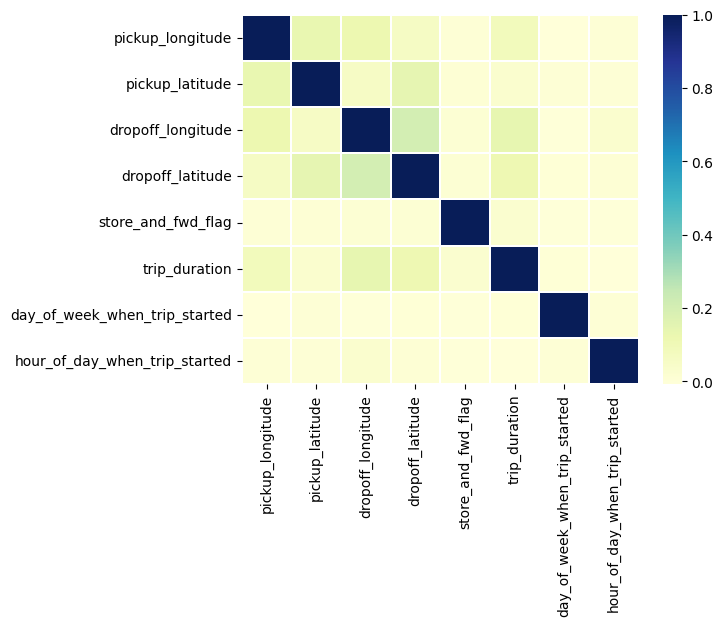

In [87]:
corr = df_corr.apply(lambda x: pd.factorize(x)[0]).corr()
ax = sns.heatmap(corr, xticklabels = corr.columns, yticklabels = corr.columns,
                 linewidths = .2, cmap = "YlGnBu")